[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_06/MFM_ch6_copula_banks/MFM_ch6_copula_banks.ipynb)

# MFM_ch6_copula_banks

Copulas for JPMorgan Chase and Bank of America (daily, 2010-2026): GARCH filtering, pseudo-observations, canonical maximum likelihood for five families, AIC, Rosenblatt Cramer-von Mises goodness-of-fit tests with parametric bootstrap and empirical tail dependence against the fitted t copula.

*Modelling Financial Markets (MFM), Chapter 6: Multivariate Volatility and Dependence. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
try:
    from arch import arch_model
except ImportError:                      # Colab: pip install arch
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
    from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
FAM_COL = {'gaussian': MainBlue, 't': IDAred, 'clayton': Forest, 'gumbel': Amber, 'frank': Purple}

SIDE = (5.6, 3.5)   # graficele asezate langa text pe slide (coloana de 0.55 din latime)

SEED = 42
NUM = {}
TABLE_DIR = '.'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def shade_crises(ax, alpha=0.12):
    for a, b in (('2008-09-15', '2009-03-31'), ('2020-02-20', '2020-04-30'), ('2022-01-03', '2022-10-31')):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=Gray, alpha=alpha, lw=0)

## Data

In [3]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, coloana, eticheta, data de start)
ASSETS = {
    'spy':   ('SPY.US',        'adjusted_close', 'SPY (S&P 500 ETF)',          '2002-07-30'),
    'tlt':   ('TLT.US',        'adjusted_close', 'TLT (20+y Treasury ETF)',    '2002-07-30'),
    'ief':   ('IEF.US',        'adjusted_close', 'IEF (7-10y Treasury ETF)',   '2002-07-30'),
    'sp500': ('GSPC.INDX',     'close',          'S&P 500',                    '2000-01-01'),
    'stoxx': ('STOXX50E.INDX', 'close',          'Euro Stoxx 50',              '2000-01-01'),
    'bet':   ('BET',           'close',          'BET (Romania)',              '2000-01-01'),
    'bettr': ('BETTR.INDX',    'close',          'BET-TR (Romania)',           '2014-09-23'),
    'btc':   ('BTC-USD.CC',    'close',          'Bitcoin',                    '2014-09-17'),
    'vix':   ('VIX.INDX',      'close',          'VIX',                        '2000-01-01'),
    'jpm':   ('JPM.US',        'adjusted_close', 'JPMorgan Chase',             '2010-01-01'),
    'bac':   ('BAC.US',        'adjusted_close', 'Bank of America',            '2010-01-01'),
    'dbk':   ('DBK.XETRA',     'adjusted_close', 'Deutsche Bank',              '2010-01-01'),
    'bnp':   ('BNP.PA',        'adjusted_close', 'BNP Paribas',                '2010-01-01'),
    'tlv':   ('TLV.RO',        'adjusted_close', 'Banca Transilvania',         '2010-01-01'),
    'brd':   ('BRD.RO',        'adjusted_close', 'BRD-Groupe Societe Generale', '2010-01-01'),
}
# ETF-urile listate in SUA pentru studiul de caz COVOL (Engle si Campos-Martins, 2023, Sectiunea 9)
COVOL_ETFS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY',
              'IWF', 'IWD', 'IWM', 'EFA', 'EEM', 'GLD', 'TLT', 'LQD', 'USO']
for _e in COVOL_ETFS:
    ASSETS['etf_' + _e.lower()] = (f'{_e}.US', 'adjusted_close', _e, '1999-12-31')
LABELS = {k: v[2] for k, v in ASSETS.items()}
SHORT = {'spy': 'SPY', 'tlt': 'TLT', 'ief': 'IEF', 'sp500': 'S&P 500', 'stoxx': 'Euro Stoxx 50', 'bet': 'BET',
         'bettr': 'BET-TR', 'btc': 'Bitcoin', 'vix': 'VIX', 'jpm': 'JPM', 'bac': 'BAC', 'dbk': 'DBK', 'bnp': 'BNP',
         'tlv': 'TLV', 'brd': 'BRD'}
BANKS = ['jpm', 'bac', 'dbk', 'bnp', 'tlv', 'brd']


def read_market(symbol):
    """Seria zilnica <SIMBOL> (data/market)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def load_price(name, start=None, end=END):
    """Pretul zilnic curatat dupa conventiile capitolului."""
    symbol, col, _, start0 = ASSETS[name]
    d = read_market(symbol).loc[start or start0:end]
    d = d[d[col] > 0].dropna(subset=[col])
    s = d[col]
    if name != 'btc':
        keep = s.index.dayofweek < 5                                   # fara cotatii de weekend
        vol = d['volume'].fillna(0) if 'volume' in d else pd.Series(0.0, index=d.index)
        keep &= ~((s.diff() == 0) & (vol <= 0)).values                # sarbatori: pret neschimbat SI volum zero
        s = s[keep]                                                    # (zilele cu volum si pret neschimbat raman)
    return s.rename(name)


def joint_prices(names, start=None, end=END):
    """Preturile activelor in zilele comune (join interior pe preturi)."""
    return pd.concat([load_price(n, start, end) for n in names], axis=1, join='inner').dropna()


def joint_returns(names, start=None, end=END):
    """Randamente log zilnice calculate DUPA join-ul pe preturi (zile comune)."""
    return np.log(joint_prices(names, start, end)).diff().dropna()


def weekly_returns(names, start=None, end=END):
    """Randamente log saptamanale: ultimul pret comun din fiecare saptamana (vineri), apoi diferente."""
    p = joint_prices(names, start, end)
    return np.log(p.resample('W-FRI').last()).diff().dropna()

## Dependence tools: EWMA, GARCH, DCC, Forbes-Rigobon, copulas

In [4]:
import numpy as np
import pandas as pd
from scipy import stats, optimize, integrate
from scipy.signal import lfilter
from scipy.special import gammaln
from arch import arch_model
try:
    from numba import njit
except ImportError:                      # without numba the same functions run as plain Python (slower)
    def njit(*args, **kwargs):
        return args[0] if (len(args) == 1 and callable(args[0])) else (lambda f: f)


# =============================================================================
# EWMA si fereastra mobila
# =============================================================================
def ewma_cov(R, lam=0.94, init=100):
    """Sigma_t = lam*Sigma_{t-1} + (1-lam) r_{t-1} r_{t-1}'  (prognoza pentru ziua t, fara r_t).
    Primele init observatii servesc doar la initializare: Sigma_init = covarianta lor; inainte de init, NaN."""
    X = np.asarray(R, dtype=float)
    T, N = X.shape
    S = np.full((T, N, N), np.nan)
    S[init] = np.cov(X[:init].T)
    for t in range(init + 1, T):
        S[t] = lam * S[t - 1] + (1 - lam) * np.outer(X[t - 1], X[t - 1])
    return S


def ewma_corr(R, lam=0.94, i=0, j=1):
    S = ewma_cov(R, lam)
    return pd.Series(S[:, i, j] / np.sqrt(S[:, i, i] * S[:, j, j]), index=R.index)


def rolling_corr(R, window, a=None, b=None):
    a, b = a or R.columns[0], b or R.columns[1]
    return R[a].rolling(window).corr(R[b])


def fisher_ci(rho, n, level=0.95):
    """Interval de incredere pentru corelatie prin transformarea Fisher z (date i.i.d.)."""
    z, se = np.arctanh(rho), 1 / np.sqrt(n - 3)
    q = stats.norm.ppf(0.5 + level / 2)
    return np.tanh(z - q * se), np.tanh(z + q * se)


# =============================================================================
# GARCH(1,1) univariat -- primul pas al DCC
# =============================================================================
def garch_filter(r, dist='normal'):
    """GARCH(1,1) cu medie constanta pe randamente in procente (QML).
    Intoarce parametrii, volatilitatea conditionala (%) si reziduurile standardizate."""
    res = arch_model(100 * r, mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
    z = (res.resid / res.conditional_volatility).rename(r.name)
    return res.params, res.conditional_volatility.rename(r.name), z, res.loglikelihood


def garch_all(R, dist='normal'):
    out = {c: garch_filter(R[c], dist) for c in R.columns}
    Z = pd.concat([out[c][2] for c in R.columns], axis=1)
    V = pd.concat([out[c][1] for c in R.columns], axis=1)
    P = pd.DataFrame({c: out[c][0] for c in R.columns})
    ll = sum(out[c][3] for c in R.columns)
    return P, V, Z, ll


# =============================================================================
# DCC (Engle, 2002): Q_t = (1-a-b) Qbar + a z_{t-1} z_{t-1}' + b Q_{t-1}
# =============================================================================
def dcc_path(Z, a, b, Qbar=None):
    """Matricele de corelatie R_t (T x N x N). Fiecare element al lui Q_t urmeaza o recursie
    liniara, calculata vectorial cu lfilter."""
    X = np.asarray(Z, dtype=float)
    T, N = X.shape
    Qbar = np.cov(X.T, bias=True) if Qbar is None else Qbar
    P = np.einsum('ti,tj->tij', X, X)                  # z_t z_t'
    drive = np.empty_like(P)
    drive[0] = Qbar
    drive[1:] = (1 - a - b) * Qbar + a * P[:-1]         # intrare la momentul t: foloseste z_{t-1}
    Q = lfilter([1.0], [1.0, -b], drive.reshape(T, -1), axis=0).reshape(T, N, N)
    Q[0] = Qbar
    d = np.sqrt(np.einsum('tii->ti', Q))
    return Q / (d[:, :, None] * d[:, None, :])


@njit(cache=True)
def dcc2_corr_loglik(x, y, a, b, q11b, q22b, q12b):
    """Cazul bivariat al lui dcc_corr_loglik, scris ca o singura bucla (aceeasi recursie ca dcc_path)."""
    q11, q22, q12 = q11b, q22b, q12b
    c = 1.0 - a - b
    ll = 0.0
    for t in range(len(x)):
        r = q12 / np.sqrt(q11 * q22)
        d = 1.0 - r * r
        ll += -0.5 * (np.log(d) + (x[t] * x[t] + y[t] * y[t] - 2.0 * r * x[t] * y[t]) / d - x[t] * x[t] - y[t] * y[t])
        q11 = c * q11b + a * x[t] * x[t] + b * q11
        q22 = c * q22b + a * y[t] * y[t] + b * q22
        q12 = c * q12b + a * x[t] * y[t] + b * q12
    return ll


def dcc_corr_loglik(Z, a, b, Qbar=None):
    """Partea de corelatie a log-verosimilitatii: -1/2 sum(log|R_t| + z'R_t^{-1}z - z'z)."""
    X = np.asarray(Z, dtype=float)
    if X.shape[1] == 2:
        Q = np.cov(X.T, bias=True) if Qbar is None else Qbar
        return dcc2_corr_loglik(np.ascontiguousarray(X[:, 0]), np.ascontiguousarray(X[:, 1]), float(a), float(b),
                                Q[0, 0], Q[1, 1], Q[0, 1])
    R = dcc_path(X, a, b, Qbar)
    sign, logdet = np.linalg.slogdet(R)
    quad = np.einsum('ti,tij,tj->t', X, np.linalg.inv(R), X)
    return -0.5 * np.sum(logdet + quad - np.sum(X ** 2, axis=1))


def ccc_loglik(Z):
    """CCC (Bollerslev, 1990): corelatie constanta = DCC cu a = b = 0."""
    return dcc_corr_loglik(Z, 0.0, 0.0)


def _num_hessian(f, x, h=1e-4):
    k = len(x)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * h, np.eye(k)[j] * h
            H[i, j] = (f(x + e_i + e_j) - f(x + e_i - e_j) - f(x - e_i + e_j) + f(x - e_i - e_j)) / (4 * h * h)
    return H


def dcc_fit(Z, start=(0.03, 0.95)):
    """Pasul 2 al DCC: (a, b) prin verosimilitate maxima, cu Qbar fixat la corelatia de selectie
    (correlation targeting). Erorile standard provin din hessiana pasului 2 (ignora eroarea pasului 1)."""
    X = np.asarray(Z, dtype=float)
    Qbar = np.cov(X.T, bias=True)

    def nll(p):
        a, b = p
        if a < 0 or b < 0 or a + b >= 0.9999:
            return 1e10
        return -dcc_corr_loglik(X, a, b, Qbar)

    best = None
    for s in (start, (0.01, 0.98), (0.05, 0.90), (0.10, 0.80)):
        r = optimize.minimize(nll, s, method='Nelder-Mead', options=dict(xatol=1e-7, fatol=1e-7, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    a, b = best.x
    try:
        H = _num_hessian(lambda p: -nll(p), best.x)
        se = np.sqrt(np.diag(np.linalg.inv(-H)))
    except Exception:
        se = np.array([np.nan, np.nan])
    return dict(a=a, b=b, se_a=se[0], se_b=se[1], loglik=-best.fun, Qbar=Qbar,
                R=dcc_path(X, a, b, Qbar), ccc_loglik=ccc_loglik(X))


# =============================================================================
# Forbes-Rigobon (2002)
# =============================================================================
def fr_adjust(rho_c, delta):
    """Corelatia din criza corectata pentru cresterea varianţei pietei-sursa:
    rho* = rho_c / sqrt(1 + delta (1 - rho_c^2)), delta = Var_criza/Var_calm - 1."""
    return rho_c / np.sqrt(1 + delta * (1 - rho_c ** 2))


def fr_inflation(rho, delta):
    """Corelatia masurata in criza cand corelatia adevarata nu se schimba: rho sqrt((1+delta)/(1+delta rho^2))."""
    return rho * np.sqrt((1 + delta) / (1 + delta * rho ** 2))


def fisher_z_test(rho1, n1, rho0, n0):
    """H0: rho1 <= rho0 (test unilateral, esantioane independente)."""
    z = (np.arctanh(rho1) - np.arctanh(rho0)) / np.sqrt(1 / (n1 - 3) + 1 / (n0 - 3))
    return z, 1 - stats.norm.cdf(z)


def crisis_table(ret2, source, targets, calm, crisis):
    """Corelatia calm vs criza, corectia Forbes-Rigobon si testul Fisher z pentru mai multe piete."""
    rows = []
    c0, c1 = ret2.loc[calm[0]:calm[1]], ret2.loc[crisis[0]:crisis[1]]
    delta = c1[source].var() / c0[source].var() - 1
    for tg in targets:
        r0, r1 = c0[source].corr(c0[tg]), c1[source].corr(c1[tg])
        adj = fr_adjust(r1, delta)
        n0, n1 = len(c0) // 2, len(c1) // 2          # randamente pe 2 zile suprapuse: n efectiv ~ n/2
        rows.append(dict(target=tg, rho_calm=r0, rho_crisis=r1, delta=delta, rho_adj=adj,
                         z_raw=fisher_z_test(r1, n1, r0, n0)[0], p_raw=fisher_z_test(r1, n1, r0, n0)[1],
                         z_adj=fisher_z_test(adj, n1, r0, n0)[0], p_adj=fisher_z_test(adj, n1, r0, n0)[1],
                         n_calm=len(c0), n_crisis=len(c1)))
    return pd.DataFrame(rows).set_index('target')


def exceedance_corr(x, y, qs):
    """Corelatia de depasire (Longin-Solnik, 2001): corr(x, y | x<q_x, y<q_y) pentru cozi joase si
    corr(x, y | x>q_x, y>q_y) pentru cozi inalte, la aceleasi cuantile marginale."""
    out = []
    for q in qs:
        lo = (x <= np.quantile(x, q)) & (y <= np.quantile(y, q))
        hi = (x >= np.quantile(x, 1 - q)) & (y >= np.quantile(y, 1 - q))
        out.append((q, np.corrcoef(x[lo], y[lo])[0, 1] if lo.sum() > 5 else np.nan, lo.sum(),
                    np.corrcoef(x[hi], y[hi])[0, 1] if hi.sum() > 5 else np.nan, hi.sum()))
    return pd.DataFrame(out, columns=['q', 'rho_low', 'n_low', 'rho_high', 'n_high']).set_index('q')


# =============================================================================
# Copule bivariate
# =============================================================================
FAMILIES = ['gaussian', 't', 'clayton', 'gumbel', 'frank']
FAM_LABEL = {'gaussian': 'Gaussian', 't': 'Student t', 'clayton': 'Clayton', 'gumbel': 'Gumbel', 'frank': 'Frank'}
EPS = 1e-10


def pseudo_obs(X):
    """Pseudo-observatii: rang / (n + 1), coloana cu coloana."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([stats.rankdata(X[:, k]) / (len(X) + 1) for k in range(X.shape[1])])


def kendall_tau(u, v):
    return stats.kendalltau(u, v)[0]


def spearman_rho(u, v):
    return stats.spearmanr(u, v)[0]


def _debye1(x):
    if abs(x) < 1e-8:
        return 1.0
    val = integrate.quad(lambda t: t / np.expm1(t), 0, abs(x))[0] / abs(x)
    return val if x > 0 else val + abs(x) / 2


def tau_of(fam, theta):
    """Tau Kendall implicat de parametrul copulei."""
    if fam in ('gaussian', 't'):
        return 2 / np.pi * np.arcsin(theta[0] if np.ndim(theta) else theta)
    th = float(np.atleast_1d(theta)[0])
    if fam == 'clayton':
        return th / (th + 2)
    if fam == 'gumbel':
        return 1 - 1 / th
    if fam == 'frank':
        return 1 - 4 / th * (1 - _debye1(th))


def theta_from_tau(fam, tau):
    """Inversarea relatiei tau <-> parametru (metoda momentelor pe tau Kendall)."""
    if fam in ('gaussian', 't'):
        return np.sin(np.pi * tau / 2)
    if fam == 'clayton':
        return 2 * tau / (1 - tau)
    if fam == 'gumbel':
        return 1 / (1 - tau)
    if fam == 'frank':
        return optimize.brentq(lambda th: tau_of('frank', th) - tau, 1e-6 if tau > 0 else -60, 60 if tau > 0 else -1e-6)


def tail_dep(fam, par):
    """(lambda_L, lambda_U) pentru parametrii dati."""
    if fam == 'gaussian':
        return 0.0, 0.0
    if fam == 't':
        rho, nu = par
        lam = 2 * stats.t.cdf(-np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), nu + 1)
        return lam, lam
    th = par[0]
    if fam == 'clayton':
        return 2 ** (-1 / th), 0.0
    if fam == 'gumbel':
        return 0.0, 2 - 2 ** (1 / th)
    return 0.0, 0.0


def log_density(fam, par, u, v):
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return -0.5 * np.log(1 - rho ** 2) - (rho ** 2 * (x ** 2 + y ** 2) - 2 * rho * x * y) / (2 * (1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return (gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2) - 0.5 * np.log(1 - rho ** 2)
                - (nu + 2) / 2 * np.log1p((x ** 2 + y ** 2 - 2 * rho * x * y) / (nu * (1 - rho ** 2)))
                + (nu + 1) / 2 * (np.log1p(x ** 2 / nu) + np.log1p(y ** 2 / nu)))
    th = par[0]
    if fam == 'clayton':
        return (np.log1p(th) - (1 + th) * (np.log(u) + np.log(v))
                - (2 + 1 / th) * np.log(u ** -th + v ** -th - 1))
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        Ath = A ** (1 / th)
        return (-Ath - np.log(u) - np.log(v) + (th - 1) * (np.log(lu) + np.log(lv))
                + (2 / th - 2) * np.log(A) + np.log1p((th - 1) / Ath))
    if fam == 'frank':
        e = -np.expm1(-th)
        den = e - (-np.expm1(-th * u)) * (-np.expm1(-th * v))
        return np.log(th * e) - th * (u + v) - 2 * np.log(np.abs(den))


def h_func(fam, par, u, v):
    """h(v|u) = dC(u,v)/du: functia de repartitie conditionata (transformata Rosenblatt)."""
    u = np.clip(u, EPS, 1 - EPS)
    v = np.clip(v, EPS, 1 - EPS)
    if fam == 'gaussian':
        rho = par[0]
        x, y = stats.norm.ppf(u), stats.norm.ppf(v)
        return stats.norm.cdf((y - rho * x) / np.sqrt(1 - rho ** 2))
    if fam == 't':
        rho, nu = par
        x, y = stats.t.ppf(u, nu), stats.t.ppf(v, nu)
        return stats.t.cdf((y - rho * x) / np.sqrt((nu + x ** 2) * (1 - rho ** 2) / (nu + 1)), nu + 1)
    th = par[0]
    if fam == 'clayton':
        return u ** (-th - 1) * (u ** -th + v ** -th - 1) ** (-1 / th - 1)
    if fam == 'gumbel':
        lu, lv = -np.log(u), -np.log(v)
        A = lu ** th + lv ** th
        return np.exp(-A ** (1 / th)) / u * lu ** (th - 1) * A ** (1 / th - 1)
    if fam == 'frank':
        a, b = np.expm1(-th * u), np.expm1(-th * v)
        return (a + 1) * b / (np.expm1(-th) + a * b)


def simulate(fam, par, n, rng):
    """Simulare de n perechi (u, v) din copula."""
    if fam == 'gaussian':
        rho = par[0]
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        return stats.norm.cdf(z)
    if fam == 't':
        rho, nu = par
        z = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
        w = np.sqrt(nu / rng.chisquare(nu, n))
        return stats.t.cdf(z * w[:, None], nu)
    th = par[0]
    if fam == 'clayton':          # Marshall-Olkin cu factor Gamma(1/theta)
        V = rng.gamma(1 / th, 1, n)
        E = rng.exponential(1, (n, 2))
        return (1 + E / V[:, None]) ** (-1 / th)
    if fam == 'gumbel':           # Marshall-Olkin cu factor stabil pozitiv, alpha = 1/theta (Kanter)
        al = 1 / th
        U = rng.uniform(0, np.pi, n)
        W = rng.exponential(1, n)
        S = np.sin(al * U) / np.sin(U) ** (1 / al) * (np.sin((1 - al) * U) / W) ** ((1 - al) / al)
        E = rng.exponential(1, (n, 2))
        return np.exp(-(E / S[:, None]) ** al)
    if fam == 'frank':            # inversarea functiei h
        u, w = rng.uniform(size=n), rng.uniform(size=n)
        v = -np.log1p(w * np.expm1(-th) / (w + (1 - w) * np.exp(-th * u))) / th
        return np.column_stack([u, v])


def fit_copula(fam, u, v):
    """Estimare ML pe pseudo-observatii (pseudo-verosimilitate canonica, CML)."""
    tau = kendall_tau(u, v)
    if fam == 'gaussian':
        f = lambda p: -np.sum(log_density('gaussian', [np.tanh(p[0])], u, v))
        r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2))], method='BFGS')
        par = [np.tanh(r.x[0])]
    elif fam == 't':
        f = lambda p: -np.sum(log_density('t', [np.tanh(p[0]), 2.01 + np.exp(p[1])], u, v))
        best = None
        for nu0 in (3, 6, 15):
            r = optimize.minimize(f, [np.arctanh(np.sin(np.pi * tau / 2)), np.log(nu0 - 2.01)], method='Nelder-Mead',
                                  options=dict(xatol=1e-6, fatol=1e-6))
            if best is None or r.fun < best.fun:
                best = r
        r = best
        par = [np.tanh(r.x[0]), 2.01 + np.exp(r.x[1])]
    else:
        lo, hi = {'clayton': (1e-4, 30), 'gumbel': (1.0001, 30), 'frank': (1e-4, 60)}[fam]
        f = lambda p: -np.sum(log_density(fam, [p], u, v))
        th0 = min(max(theta_from_tau(fam, max(tau, 0.02)), lo * 1.01), hi * 0.99)
        r = optimize.minimize_scalar(f, bounds=(lo, hi), method='bounded', options=dict(xatol=1e-7))
        if f(th0) < r.fun:
            r = optimize.minimize_scalar(f, bracket=(lo * 1.01, th0, hi * 0.99), bounds=(lo, hi), method='bounded')
        par = [r.x]
    ll = np.sum(log_density(fam, par, u, v))
    k = 2 if fam == 't' else 1
    lamL, lamU = tail_dep(fam, par)
    return dict(family=fam, par=list(map(float, par)), loglik=float(ll), aic=float(2 * k - 2 * ll),
                bic=float(k * np.log(len(u)) - 2 * ll), tau_model=float(tau_of(fam, par if fam in ('gaussian', 't') else par[0])),
                lamL=float(lamL), lamU=float(lamU))


def cvm_rosenblatt(fam, par, u, v, chunk=1500):
    """S_n^(B) (Genest, Remillard & Beaudoin, 2009): distanta Cramer-von Mises dintre repartitia
    empirica a perechilor Rosenblatt (u, h(v|u)) si copula de independenta."""
    E = np.column_stack([u, h_func(fam, par, u, v)])
    n = len(E)
    t1 = n / 9
    t2 = np.sum((1 - E[:, 0] ** 2) * (1 - E[:, 1] ** 2)) / 2
    t3 = 0.0
    for i in range(0, n, chunk):
        Ei = E[i:i + chunk]
        t3 += np.sum((1 - np.maximum(Ei[:, None, 0], E[None, :, 0])) * (1 - np.maximum(Ei[:, None, 1], E[None, :, 1])))
    return t1 - t2 + t3 / n


def gof_test(fam, u, v, B=200, seed=42, fit=None):
    """Test de adecvare cu bootstrap parametric: simulare din copula estimata, pseudo-observatii,
    re-estimare, statistica S_n^(B); p-valoarea = proportia statisticilor bootstrap >= cea observata."""
    fit = fit or fit_copula(fam, u, v)
    s0 = cvm_rosenblatt(fam, fit['par'], u, v)
    rng = np.random.default_rng(seed)
    sb = []
    for _ in range(B):
        X = simulate(fam, fit['par'], len(u), rng)
        U = pseudo_obs(X)
        fb = fit_copula(fam, U[:, 0], U[:, 1])
        sb.append(cvm_rosenblatt(fam, fb['par'], U[:, 0], U[:, 1]))
    sb = np.array(sb)
    return dict(stat=float(s0), p=float((1 + np.sum(sb >= s0)) / (B + 1)), B=B)


def empirical_tail_dep(u, v, q):
    """lambda_L(q) = P(U<=q, V<=q)/q si lambda_U(q) = P(U>1-q, V>1-q)/q."""
    return np.mean((u <= q) & (v <= q)) / q, np.mean((u > 1 - q) & (v > 1 - q)) / q

## Analysis

In [5]:
def bank_copula_data():
    R = joint_returns(['jpm', 'bac'])
    P, V, Z, ll = garch_all(R)
    U = pseudo_obs(Z.values)
    return R, Z, U


def fig_pseudo_obs(Z, U):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
    axes[0].scatter(Z['jpm'], Z['bac'], s=2, color=MainBlue, alpha=0.35, label='GARCH standardised residuals')
    axes[0].set_xlabel('JPM')
    axes[0].set_ylabel('BAC')
    axes[1].scatter(U[:, 0], U[:, 1], s=2, color=IDAred, alpha=0.35, label='Pseudo-observations (ranks / (n+1))')
    axes[1].set_xlabel('JPM (uniform scale)')
    axes[1].set_ylabel('BAC (uniform scale)')
    h = [axes[0].collections[0], axes[1].collections[0]]
    fig.legend(h, [x.get_label() for x in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False,
               markerscale=4)
    plt.tight_layout()
    save_fig('ch6_pseudo_obs')


def copula_table(U, B=200, B_t=100):
    u, v = U[:, 0], U[:, 1]
    rows = []
    for fam in FAMILIES:
        f = fit_copula(fam, u, v)
        g = gof_test(fam, u, v, B=B_t if fam == 't' else B, seed=SEED, fit=f)
        rows.append(dict(family=fam, par1=f['par'][0], par2=f['par'][1] if fam == 't' else np.nan, loglik=f['loglik'],
                         aic=f['aic'], bic=f['bic'], tau_model=f['tau_model'], lamL=f['lamL'], lamU=f['lamU'],
                         gof_stat=g['stat'], gof_p=g['p'], gof_B=g['B']))
    return pd.DataFrame(rows).set_index('family')


def fig_copula_fit(U):
    t = copula_table(U)
    t.to_csv(os.path.join(TABLE_DIR, 'ch6_copula_jpm_bac.csv'), float_format='%.6g')
    fig, ax = plt.subplots(figsize=SIDE)
    d = t['aic'] - t['aic'].min()
    ax.bar(np.arange(5), d, color=[FAM_COL[f] for f in t.index])
    for i, (fam, val) in enumerate(d.items()):
        ax.text(i, val + d.max() * 0.02, f'p = {t.loc[fam, "gof_p"]:.3f}', ha='center', fontsize=7)
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels([FAM_LABEL[f] for f in t.index])
    ax.set_ylabel('AIC minus best AIC')
    ax.plot([], [], ' ', label='Numbers above bars: goodness-of-fit p-value\n(Rosenblatt Cramer-von Mises, parametric bootstrap)')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1, frameon=False, handlelength=0)
    save_fig('ch6_copula_fit')
    u, v = U[:, 0], U[:, 1]
    NUM.update(cop_n=len(U), cop_tau=kendall_tau(u, v), cop_rhoS=spearman_rho(u, v))
    for fam in t.index:
        for c in ('par1', 'par2', 'loglik', 'aic', 'lamL', 'lamU', 'gof_stat', 'gof_p', 'tau_model'):
            NUM[f'cop_{fam}_{c}'] = t.loc[fam, c]
        NUM[f'cop_{fam}_daic'] = d[fam]
    NUM['cop_best'] = t['aic'].idxmin()
    return t


def fig_tail_dep(U, t):
    u, v = U[:, 0], U[:, 1]
    qs = np.linspace(0.01, 0.20, 20)
    emp = np.array([empirical_tail_dep(u, v, q) for q in qs])
    rng = np.random.default_rng(SEED)
    # banda de referinta: aceeasi estimare pe date simulate din copula t estimata (200 de replicari)
    par_t = [t.loc['t', 'par1'], t.loc['t', 'par2']]
    sims = []
    for _ in range(200):
        X = pseudo_obs(simulate('t', par_t, len(u), rng))
        sims.append([empirical_tail_dep(X[:, 0], X[:, 1], q)[0] for q in qs])
    sims = np.array(sims)
    fig, ax = plt.subplots(figsize=SIDE)
    ax.fill_between(qs, np.percentile(sims, 5, axis=0), np.percentile(sims, 95, axis=0), color=IDAred, alpha=0.15, lw=0,
                    label='90% band of the estimator under the fitted t copula')
    ax.plot(qs, emp[:, 0], 'o-', ms=3, color=IDAred, label='Empirical lower tail: P(U<=q, V<=q) / q')
    ax.plot(qs, emp[:, 1], 's-', ms=3, color=Forest, label='Empirical upper tail: P(U>1-q, V>1-q) / q')
    ax.axhline(t.loc['t', 'lamL'], color=IDAred, ls='--', lw=0.9, label=f't copula limit: {t.loc["t", "lamL"]:.2f}')
    ax.axhline(t.loc['clayton', 'lamL'], color=Forest, ls=':', lw=0.9, label=f'Clayton lower limit: {t.loc["clayton", "lamL"]:.2f}')
    ax.axhline(t.loc['gumbel', 'lamU'], color=Amber, ls=':', lw=0.9, label=f'Gumbel upper limit: {t.loc["gumbel", "lamU"]:.2f}')
    ax.set_xlabel('q')
    ax.set_ylabel('Tail dependence estimate')
    ax.set_ylim(0, 1)
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch6_tail_dep')
    i5 = np.argmin(np.abs(qs - 0.05))
    NUM.update(td_L05=emp[i5, 0], td_U05=emp[i5, 1], td_L01=emp[0, 0], td_U01=emp[0, 1],
               td_band05_lo=np.percentile(sims[:, i5], 5), td_band05_hi=np.percentile(sims[:, i5], 95))

## Run

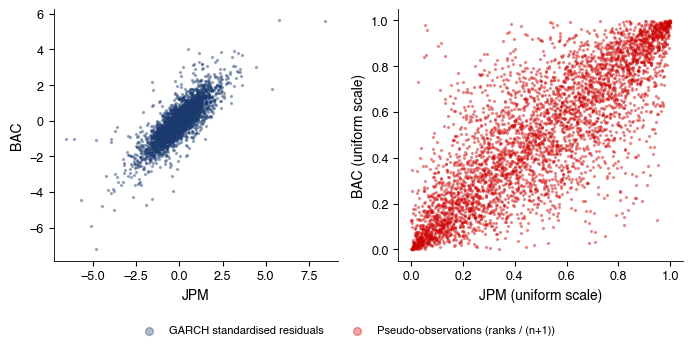

   saved ch6_pseudo_obs


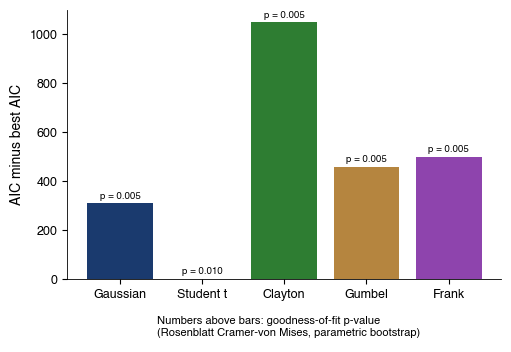

   saved ch6_copula_fit


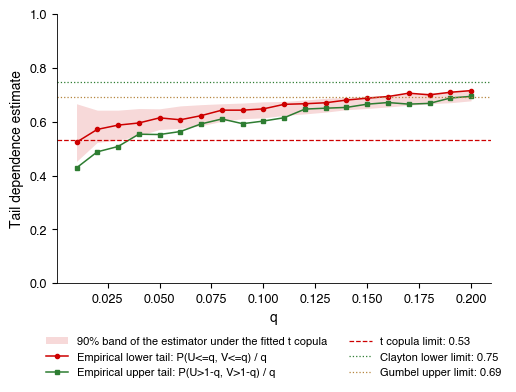

   saved ch6_tail_dep


,par1,par2,loglik,aic,bic,tau_model,lamL,lamU,gof_stat,gof_p,gof_B
family,,,,,,,,,,,
gaussian,0.833,NaN,2486.019,-4970.038,-4963.695,0.627,0.000,0.000,0.968,0.005,200
t,0.842,4.241,2641.675,-5279.350,-5266.663,0.637,0.531,0.531,0.082,0.010,100
clayton,2.384,NaN,2116.660,-4231.320,-4224.977,0.544,0.748,0.000,1.243,0.005,200
gumbel,2.587,NaN,2412.239,-4822.478,-4816.135,0.613,0.000,0.693,1.418,0.005,200
frank,9.152,NaN,2390.764,-4779.528,-4773.184,0.641,0.000,0.000,0.365,0.005,200


In [6]:
Rb, Zb, Ub = bank_copula_data()
fig_pseudo_obs(Zb, Ub)
tb = fig_copula_fit(Ub)
fig_tail_dep(Ub, tb)
tb.round(3)

![ch6_pseudo_obs](./ch6_pseudo_obs.png)

Output: `ch6_pseudo_obs.pdf`

![ch6_copula_fit](./ch6_copula_fit.png)

Output: `ch6_copula_fit.pdf`

![ch6_tail_dep](./ch6_tail_dep.png)

Output: `ch6_tail_dep.pdf`